# Modelamiento ARMA de la Tasa Representativa del Mercado

Identificación, estimación y diagnóstico de un modelo ARMA sobre la TRM siguiendo la metodología Box-Jenkins. El desarrollo continua el de la unidad 1, en la cual se estableció que la serie en nivel no es estacionaria y que su primera diferencia logarítmica si satisface las condiciones de estacionariedad débil. 

**Fuente de datos:** Banco de la República de Colombia, Portal de Estadísticas Económicas. Serie diaria de la Tasa Representativa del Mercado, Noviembre de 1991 a Agosto de 2026.

---
## Preparación del entorno

In [6]:
import warnings
warnings.filterwarnings("ignore")

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización 
import matplotlib.pyplot as plt
import seaborn as sns

# Series de tiempo 
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

### Serie de trabajo para esta unidad

En la unidad 1 el análisis se desarrollo sobre el log-retorno diario de la TRM. Para esta unidad se trabaja sobre el **log-retorno del promedio mensual**, que esta definido como

$$y_t = \Delta\log(\overline{TRM}_t) \times100$$

donde $\overline{TRM}_t$ corresponde al promedio de la TRM durante el mes $t$.

Se emplea esta metodología debido a una decisión propia, la cual se adoptó por dos consideraciones que se documentan con evidencia en la sección 3. 

La primera consideración surge de la banda de confianza utilizada para juzgar la significancia de los coeficientes de la ACF el cual se calcula como $\pm 1.96/\sqrt{n}$ bajo la hipótesis nula de ruido blanco (Box et al., 2015),  de modo que su amplitud depende directamente del tamaño muestral. Teniendo esto en cuenta, las dos frecuencias producen bandas de amplitud muy distinta, y en la sección 5.1 se cuantifica el efecto que esto tiene sobre el número de rezagos que resultan marcados como significativos en cada caso.

La segunda consideración se relaciona con la frecuencia diaria y como está incorpora el efecto de la regla de publicación que se logró identificar en la unidad 1, según la cual sábados, domingos y festivos adoptan la TRM vigente del día hábil inmediatamente siguiente (Banco de la República, 2018). Debido a lo anterior, el promedio mensual agrega conjuntamente los días hábiles y los heredados dentro de cada mes, por lo que los valores repetidos no aparecen como observaciones independientes de la serie modelada.

Finalmente es necesario tener en cuenta que la serie diaria no será descartada,  sino que se reserva para la etapa final del proyecto por las razones que se exponen en la sección 4. 


In [7]:
url = ("https://raw.githubusercontent.com/Juanhv24/Time-Series-Colombia/"
       "main/data/raw/Tasa%20de%20cambio%20del%20peso%20colombiano.csv")

trm = pd.read_csv(url)
trm.columns = ["fecha", "trm"]
trm["fecha"] = pd.to_datetime(trm["fecha"], format="%Y/%m/%d")

# Promedio mensual de la TRM y su log-retorno en porcentaje
trm_mensual = trm.set_index("fecha")["trm"].resample("MS").mean()
y = (np.log(trm_mensual).diff() * 100).dropna()
y.name = "log_retorno_mensual"

print(f"Meses disponibles: {len(trm_mensual)}")
print(f"Observaciones de la serie modelada: {len(y)}")
print(f"Periodo: {trm_mensual.index.min().date()} a {trm_mensual.index.max().date()}")
print(f"Media: {y.mean():.4f} | Desviación estándar: {y.std():.4f}")

Meses disponibles: 418
Observaciones de la serie modelada: 417
Periodo: 1991-11-01 a 2026-08-01
Media: 0.3606 | Desviación estándar: 2.9440


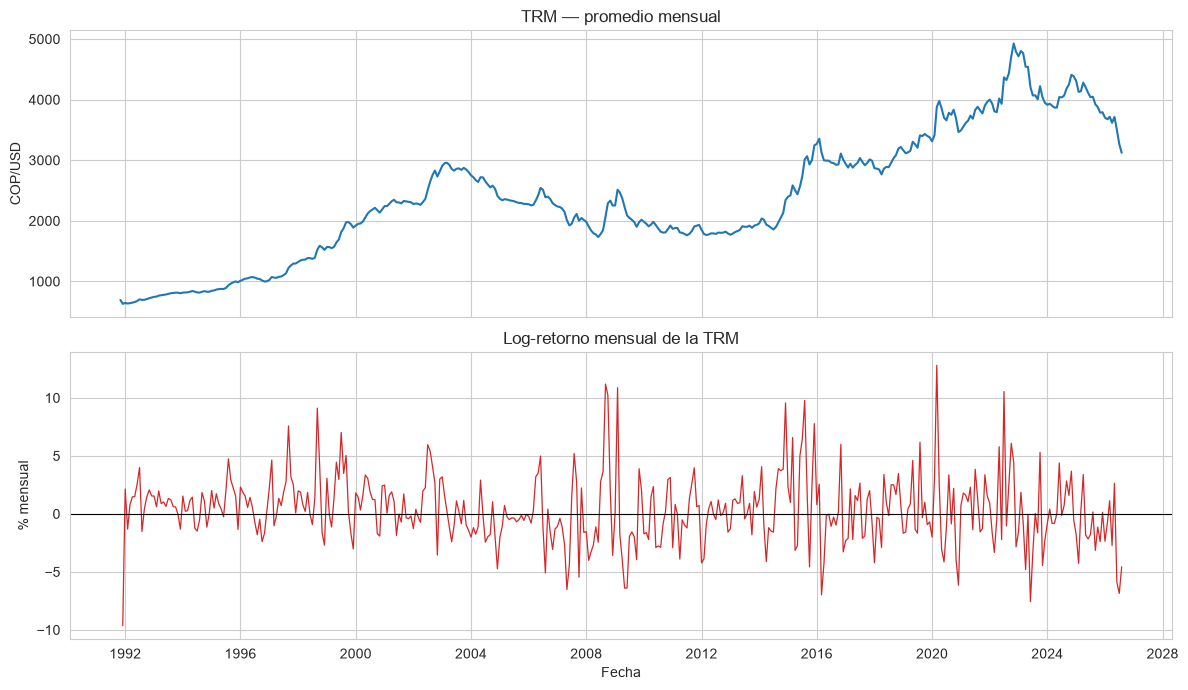

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(trm_mensual.index, trm_mensual.values, color="#1f77b4")
axes[0].set_title("TRM — promedio mensual")
axes[0].set_ylabel("COP/USD")

axes[1].plot(y.index, y.values, color="#d62728", linewidth=0.9)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Log-retorno mensual de la TRM")
axes[1].set_ylabel("% mensual")
axes[1].set_xlabel("Fecha")

plt.tight_layout()
plt.savefig("../reports/figures/10_trm_mensual.png", dpi=150)
plt.show()

**Interpretación:** A partir de la gráfica podemos observar dos paneles, en el superior la TRM promedio mensual la cual conserva la tendencia creciente del largo plazo que se identificó en la unidad 1, aunque con una trayectoria un poco suavizada. Por otro lado, en el panel inferior el log-retorno mensual oscila en torno a cero durante todo el periodo, con episodios de mayor amplitud que coinciden con los tramos de depreciación acelerada descritos en la unidad 1. 

### Prueba de hipótesis para estacionariedad 

|Prueba|$H_0$|$H_1$|Conclusión si se rechaza $H_0$|
|---|---|---|---|
|**ADF**|La serie tiene raíz unitaria|La serie es estacionaria|Estacionaria|
|**KPSS**|La serie es estacionaria|La serie tiene raíz unitaria|No estacionaria|

Ambas pruebas plantean hipótesis nulas opuestas, razón por la cual se aplican de forma conjunta (Dickey & Fuller, 1979; Kwiatkowski et al., 1992). Teniendo en cuenta que la estacionariedad es el supuesto sobre el cual descansa toda la metodología Box-Jenkins, es necesario hacer la verificación antes de avanzar.

In [9]:
adf = adfuller(y)
kps = kpss(y, regression="c", nlags="auto")

print(f"ADF  : estadístico = {adf[0]:8.4f} | p-valor = {adf[1]:.4f}")
print(f"KPSS : estadístico = {kps[0]:8.4f} | p-valor = {kps[1]:.4f}\n")
print("ADF  ->", "estacionaria" if adf[1] < 0.05 else "no estacionaria")
print("KPSS ->", "estacionaria" if kps[1] >= 0.05 else "no estacionaria")

ADF  : estadístico = -12.6162 | p-valor = 0.0000
KPSS : estadístico =   0.3602 | p-valor = 0.0943

ADF  -> estacionaria
KPSS -> estacionaria


**Interpretación:** Ambas pruebas coinciden en clasificar el log-retorno mensual como estacionario, por lo que la serie cumple el requisito de la etapa de identificación y no requiere diferenciación adicional. Teniendo en cuenta lo anterior, el orden de integración sobre esta variable es $d=0$, lo que es equivalente a un $d=1$ sobre el logaritmo del promedio mensual de la TRM.

---
# 1. Ciclo de trabajo
En este caso se aplica la metodología Box-Jenkins la cual construye el modelo a partir de la propia estructura de dependencia de los datos, recorriendo tres etapas de forma iterativa (Box et al., 2015).

1.	**Identificación:** Se verifica la estacionariedad a partir de la lectura de ACF y PACF para proponer modelos tentativos. 
2.	**Estimación:** Se realiza el ajuste de parámetros y se evalúa su significado. 
3.	**Diagnóstico:** Se realiza la comprobación de que los residuos se comportan como ruido blanco.

Una cuarta etapa en este caso el pronóstico, corresponde a la fase siguiente del proyecto. 

El criterio que se aplicará de forma transversal es el principio de parsimonia, según el cual entre modelos con desempeño comparable es preferible aquel que emplea menos parámetros (Box et al., 2015), como se verá en la sección 3, este principio es determinante, ya que criterios de información por si solos no permiten resolver la elección. 

Las lecciones 2 a 4 recorren las tres etapas mencionadas sobre la TRM.


---
# 2. Identificación: ¿Qué tipo de memoria tiene la serie?
La etapa de identificación consiste en reconocer cómo persiste el pasado dentro de la serie, para lo cual se contemplan tres familias de modelos que precisamente cuentan con una metodología que se distingue por el tipo de memoria que suponen. 

|Familia |Que recuerda la serie |Firma en la ACF |Firma en la PACF |
|---|---|---|---|
|**AR(p)** |Sus propios valores pasados | Decae gradualmente |Se corta en el rezago $p$ |
|**MA(q)** | Los choques pasados |Se corta en el rezago $q$ |Decae gradualmente |
|**ARMA(p, q)** |Valores y choques a la vez |Decae gradualmente |Decae gradualmente |

Estas firmas son consecuencias directas de la forma de cada modelo y constituyen la herramienta central de la etapa (Box et al., 2015). Cada familia será definida formalmente en la sección 3, donde contrasta con los resultados que produce sobre esta serie. Previo a la lectura de las funciones de autocorrelación es conveniente saber que esperar teniendo en cuenta cómo se construye la TRM.


---
## 2.1 Qué cabe esperar dado cómo se construye la TRM
En la unidad previa se llegó a la conclusión de que el log-retorno se aproxima a un proceso de ruido blanco, este resultado es consistente con la hipótesis de eficiencia del mercado, según la cual el precio de un activo en un mercado eficiente incorpora toda la información disponible y sus variaciones no son predecibles a partir del pasado (Fama, 1970). Teniendo en cuenta este supuesto, no debería existir estructura alguna que modelar. Sin embargo, la TRM no es un precio de cierre, sino que corresponde al promedio ponderado de las operaciones de compra y venta de dólares registradas durante la jornada (Banco de la República, 2018), además cabe resaltar que la serie de esta unidad añade una segunda capa de promediado al calcular la media mensual de esos valores diarios. 

A partir de esta distinción se deriva una consecuencia concreta, que tiene validez ya que Working (1960) demostró que la agregación temporal de una caminata aleatoria induce correlación serial positiva en las primeras diferencias que no está presente en la serie subyacente y que dicho efecto se manifiesta como una estructura de media móvil de primer orden, con una autocorrelación teórica cercana a 0.25.
El mecanismo mencionado previamente es intuitivo si se piensa en términos de memoria ya que dos promedios consecutivos no comparten valores, pero sí comparten los choques que ocurren dentro del periodo que ambos abarcan, lo que quiere decir, que la serie no arrastra su nivel anterior sino las perturbaciones anteriores, que es exactamente lo que se describe en un modelo MA.

En conjunto lo previamente mencionado permite plantear una hipótesis antes de mirar los datos, la cual es que, si la estructura que aparezca proviene del método de cálculo y no del comportamiento del mercado, la ACF debería cortarse en el primer rezago y el coeficiente estimado debería ubicarse en el orden de 0.25 y con signo positivo, esta será contrastada en las siguientes secciones. 


---
## 2.2 Funciones de autocorrelación observadas

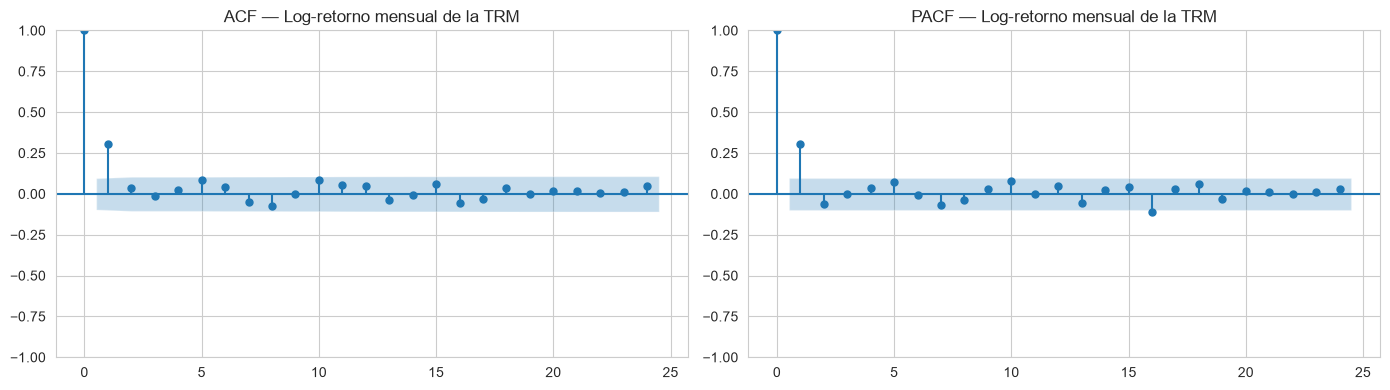

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y, lags=24, ax=axes[0])
axes[0].set_title("ACF — Log-retorno mensual de la TRM")
plot_pacf(y, lags=24, ax=axes[1])
axes[1].set_title("PACF — Log-retorno mensual de la TRM")
plt.tight_layout()
plt.savefig("../reports/figures/11_acf_pacf_mensual.png", dpi=150)
plt.show()

Debido a que la lectura visual de las bandas puede resultar ambigua cuando los coeficientes son pequeños, se decide acompañar el gráfico con los valores numéricos y el umbral de significancia, calculado como $\pm 1.96/\sqrt{n}$ bajo la hipótesis nula de ruido blanco (Box et al., 2015).

In [11]:
n = len(y)
banda = 1.96/np.sqrt(n)

a = acf(y, nlags=12)
p = pacf(y, nlags=12)

tabla_id = pd.DataFrame({
    "rezago": range(1, 13),
    "ACF": a[1: 13].round(4),
    "PACF": p[1: 13].round(4),
})
tabla_id["ACF_signif"] = np.where(np.abs(tabla_id["ACF"]) > banda, "Sí", "No")
tabla_id["PACF_signif"] = np.where(np.abs(tabla_id["PACF"]) > banda, "Sí", "No")

print(f"n = {n} | umbral de significancia = ±{banda:.4f}\n")
print(tabla_id.to_string(index=False))

n = 417 | umbral de significancia = ±0.0960

 rezago     ACF    PACF ACF_signif PACF_signif
      1  0.3031  0.3038         Sí          Sí
      2  0.0329 -0.0653         No          No
      3 -0.0117 -0.0029         No          No
      4  0.0245  0.0349         No          No
      5  0.0858  0.0753         No          No
      6  0.0443 -0.0053         No          No
      7 -0.0529 -0.0708         No          No
      8 -0.0731 -0.0363         No          No
      9 -0.0034  0.0316         No          No
     10  0.0877  0.0796         No          No
     11  0.0532 -0.0019         No          No
     12  0.0491  0.0508         No          No


**Interpretación:** A partir de lo que se observa tanto la ACF como la PACF presentan un único coeficiente significativo en el primer rezago, con valores de 0.3031 y 0.3038 respectivamente, mientras que la totalidad de los rezagos restantes caen dentro del umbral.

Teniendo en cuenta los resultados, si los contrastamos con la hipótesis previamente planteada, el valor de 0.3031 es del mismo signo y del mismo orden de magnitud que el 0.25 que anticipo a partir del efecto de agregación temporal (Working, 1960) y la ACF se corta después del primer rezago tal como se había previsto, por ende, la predicción hecha en la sección 2.1 resulta compatible con lo observado.
 
A pesar de lo anterior, la evidencia gráfica no es suficiente para cerrar la elección, ya que el corte se produce simultáneamente en ambas funciones. Según la tabla de la sección 2, un corte de la ACF apunta a un modelo MA y un corte en PACF apunta a un modelo AR, de tal modo que la firma observada es compatible con las dos especificaciones de orden uno. Esta ambigüedad es esperable cuando el coeficiente es de magnitud moderada, lo que obliga a complementar la lectura gráfica con criterios formales. 

Con lo que respecta la estacionalidad, el rezago 12, donde se manifestaría un patrón anual en una serie mensual presenta un valor de 0.0491 en la ACF por lo que no resulta significativa y no se requiere un componente estacional. 

En consecuencia, los modelos tentativos que pasan a la etapa de estimación son AR(1), MA(1) y como alternativa que engloba a ambos ARMA(1, 1).


---
# 3. Estimación: cada candidato frente a los datos
En esta sección se realiza la evaluación de los tres modelos tentativos, en donde cada uno será presentado con su forma general y posteriormente con el resultado que produce sobre la serie. 

## 3.1 Panorama general 
Antes de examinar los modelos uno por uno, se hace un ajuste de la grilla de los modelos $ARMA(p, q)$ con $p, q \in \{0, 1, 2, 3\}$, comparados mediante los criterios de información de Akaike (1974) y de Schwarz (1978). Ambos criterios penalizan el número de parámetros, aunque el segundo lo hace con más severidad, por lo que tiende a favorecer modelos más parsimoniosos. 


In [12]:
resultados = []

for p_ord in range(0, 4):
    for q_ord in range (0, 4):
        if p_ord == 0 and q_ord == 0:
            continue
        try:
            mod = ARIMA(y, order=(p_ord, 0, q_ord)).fit()
            resultados.append({
                "p": p_ord, "q": q_ord,
                "parámetros": p_ord + q_ord,
                "AIC": round(mod.aic, 2),
                "BIC": round(mod.bic, 2),
            })
        except Exception:
            pass

grilla = pd.DataFrame(resultados)
grilla["delta_AIC"] = (grilla["AIC"] - grilla["AIC"].min()).round(2)

print("Cinco mejores modelos según AIC:")
print(grilla.sort_values("AIC").head().to_string(index=False))
print("\nCinco mejores modelos según BIC:")
print(grilla.sort_values("BIC").head(5).to_string(index=False))

Cinco mejores modelos según AIC:
 p  q  parámetros     AIC     BIC  delta_AIC
 2  3           5 2045.58 2073.81       0.00
 0  1           1 2046.20 2058.30       0.62
 1  0           1 2047.34 2059.44       1.76
 2  0           2 2047.36 2063.50       1.78
 0  2           2 2047.40 2063.54       1.82

Cinco mejores modelos según BIC:
 p  q  parámetros     AIC     BIC  delta_AIC
 0  1           1 2046.20 2058.30       0.62
 1  0           1 2047.34 2059.44       1.76
 2  0           2 2047.36 2063.50       1.78
 0  2           2 2047.40 2063.54       1.82
 1  1           2 2047.46 2063.59       1.88


**Interpretación:** Se evidencia que el modelo de menor AIC es un ARMA (2, 3), seguido de cerca por el MA(1) que en cambio encabeza el ordenamiento por BIC. Para determinar si esta diferencia es relevante, es conveniente acudir a la escala convencional de interpretación del $\Delta AIC$, según la cual los modelos situados dentro de 2 unidades del mejor cuentan con apoyo sustancial de los datos, y solo por encima de 10 unidades el apoyo se considera inexistente (Burnham & Anderson, 2002). El MA(1) presenta un $\Delta AIC$ de 0.62, de modo que ambos modelos están igualmente respaldados por este criterio. 

Teniendo en cuenta lo anterior, la elección del modelo no se puede resolver por AIC y debe apoyarse en la parsimonia, criterio que favorece al MA(1), ya que emplea un solo parámetro frente a los cinco que emplea ARMA(2, 3) (Box et al., 2015), además el ordenamiento por BIC respalda esa conclusión. En la siguiente sección se examina en detalle los tres candidatos identificados. 

## 3.2 Modelo Autorregresivo: AR(1)

Los modelos **AR(p)** suponen que la serie recuerda sus propios valores pasados y expresa el valor actual como una combinación lineal de ellos más un término de error (Box et al., 2015)

$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \dots + \phi_p Y_{t-p} + \varepsilon_t$$

donde $c$ es una constante, $\phi_i$ son los coeficientes autorregresivos y $\varepsilon_t$ es ruido blanco.Para el caso de orden uno, la especificación se reduce a $Y_t = c + \phi_1Y_{t-1} + \varepsilon_t$, teniendo esto en cuenta es relavante saber que el modelo es estacionario si $|\phi_1| < 1$.

In [13]:
modelo_ar1 = ARIMA(y, order=(1, 0, 0)).fit()
print(modelo_ar1.summary().tables[1])
print(f"\nAIC = {modelo_ar1.aic:.2f} | BIC = {modelo_ar1.bic:.2f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3444      0.204      1.688      0.091      -0.055       0.744
ar.L1          0.3132      0.039      7.934      0.000       0.236       0.391
sigma2         7.8238      0.391     19.989      0.000       7.057       8.591

AIC = 2047.34 | BIC = 2059.44


**Interpretación:** En los resultados se observa como el coeficiente autorregresivo estimado es de 0.3132 y resulta significativo, con un p-valor inferior a 0.001, por lo que el modelo satisface además la condición de estacionariedad al ser su valor absoluto inferior a la unidad. L constante, en cambio, presenta un p-valor de 0.091 y no alcanza el umbral de 5%. Bajo esta especificación, la interpretación sería que el retorno de un mes arrastra directamente el nivel del retorno del mes anterior, esto se puede interpretar como un ajuste admisible y su desempeño se compara con el de las alternativas restante en la sección 3.5.

## 3.3 Modelo de media móvil: MA(1):

Los modelos **MA(q)** suponen que lo que la serie arrastra no son sus valores sino los choques pasados, de tal forma que expresa un valor actual como una combinación lineal del error actual y de los anteriores (Box et al., 2015): 

$$Y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q}$$

donde $\mu$ es la media del proceso y $\theta_i$ los coeficientes de media móvil. Para el caso de orden uno, la especificación se reduce a $Y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1}$- El modelo es invertible si $|\theta_1| < 1$, condición necesaria para que la representación sea única y admita una forma autorregresiva equivalente. 

Esta es la familia que se anticipaba en la hipóteisis de la sección 2.1, dado que dos promedios consecutivos comparten choques y no valores. 

In [14]:
modelo_ma1 = ARIMA(y, order=(0, 0, 1)).fit()
print(modelo_ma1.summary().tables[1])
print(f"\nAIC = {modelo_ma1.aic:.2f} | BIC = {modelo_ma1.bic:.2f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3498      0.187      1.874      0.061      -0.016       0.716
ma.L1          0.3212      0.037      8.739      0.000       0.249       0.393
sigma2         7.8024      0.384     20.320      0.000       7.050       8.555

AIC = 2046.20 | BIC = 2058.30


**Interpretación:** El coeficiente de media móvil estimado es de 0.3212, con un p-valor inferior a 0.001, lo que satisface la condición de invertibilidad y siendo la lectura que el choque del mes previo se transmite de forma parcial y positiva al mes actual. 

Para respaldar esta la especificación previamente mencionada tenemos dos elementos, por un lado, se da una mejora con respecto al modelo AR(1) en ambos criterios de información, con 2046.20 frente 2047.34 en AIC y 2058.30 frente a 2059.44 en BIC. Por otro lado, el valor estimado se aproxima a 0.25 que predice el efecto de agregación temporal (Working, 1960), mientras que un coeficiente autorregresivo de magnitud similar no tendría una explicación equivalente en el mecanismo de construcción de la serie. 

Al igual que en el AR(1), la constante no resulta significativa, con un p-valor de 0.061, situación que será interpretada en la sección 3.5. 


## 3.4 Modelo mixto: ARMA(1,1)

Los modelos **ARMA(p,q)** combinan ambos tipos de memoria, esto se da debido a que incorporan simultaneamente los valores y los choques pasados (Box et al., 2015).

$$Y_t = c + \phi_1 Y_{t-1} + \dots + \phi_p Y_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}$$

Es más flexible que las dos familias anteriores y permite capturar dinámicas más complejas con pocos parámetros, aunque requiere satisfacer a la vez condición de estacionariedad de la parte AR y la de invertibilidad de la parte MA, en este caso para ARMA(1,1) la especificación se reduce a $Y_t = c + \phi_1 Y_{t-1} + \varepsilon_t + \theta_1 \varepsilon_{t-1}$.


In [15]:
modelo_arma11 = ARIMA(y, order=(1, 0, 1)).fit()
print(modelo_arma11.summary().tables[1])
print(f"\nAIC = {modelo_arma11.aic:.2f} | BIC = {modelo_arma11.bic:.2f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3477      0.195      1.786      0.074      -0.034       0.729
ar.L1          0.1296      0.133      0.972      0.331      -0.132       0.391
ma.L1          0.2051      0.127      1.616      0.106      -0.044       0.454
sigma2         7.7886      0.389     20.011      0.000       7.026       8.551

AIC = 2047.46 | BIC = 2063.59


**Interpretación:** A partir de los resultados podemos observar que ninguno de los coeficientes resulta significativo al 5%, ya que el autorregresivo presenta un p-valor de 0.331 y el de media móvil de 0.106, a pesar de que ambos llegaron a alcanzar significancia al estimarse por separado en las secciones anteriores. El comportamiento descrito es un síntoma característico de una especificación sobreparametrizada, ya que al incluir simultáneamente un termino AR y uno MA que compiten por explicar una misma estructura de primer orden, las estimaciones se reparten el efecto y ninguna alcanza la precisión suficiente. Además, el modelo es el que peor desempeño muestra de los tres evaluados en ambos criterios, con 2047.46 en AIC y 2063.59 en BIC, de modo que el parámetro adicional no compensa su costo. A partir de lo anterior, el **ARMA(1,1) queda descartado**, lo cual es una conclusión que es respaldada por el principio de parsimonia al preferir la especificación con menos parámetros entre alternativas de desempeño comparable (Box et al., 2015).

## 3.5 Modelo seleccionado y expresión

In [16]:
comparacion = []
for nombre, mod, k in [("AR(1)", modelo_ar1, 1),
                       ("MA(1)", modelo_ma1, 1),
                       ("ARMA(1,1)", modelo_arma11, 2)]:
    no_signif = [c for c in mod.params.index
                 if c != "sigma2" and mod.pvalues[c] >= 0.05]
    comparacion.append({
        "Modelo": nombre,
        "Parámetros": k,
        "AIC": round(mod.aic, 2),
        "BIC": round(mod.bic, 2),
        "Coef. no significativos": ", ".join(no_signif) if no_signif else "ninguno",
    })

print(pd.DataFrame(comparacion).to_string(index=False))

   Modelo  Parámetros     AIC     BIC Coef. no significativos
    AR(1)           1 2047.34 2059.44                   const
    MA(1)           1 2046.20 2058.30                   const
ARMA(1,1)           2 2047.46 2063.59     const, ar.L1, ma.L1


**Interpretación:** Al momento de realizar la comparación de los modelos, podemos confirmar la selección de **MA(1)**, ya que es el modelo que presenta los mejores valores en ambos criterios de información entre los tres candidatos, utilizando un solo parámetro y conservando su coeficiente significativo. Remplazando los valores estimados en la forma general presentada en la sección 3.3 el modelo resultante es 

$$y_t = 0.3498 + \varepsilon_t + 0.3212\,\varepsilon_{t-1}$$


Donde $y_t$ es el log-retorno mensual del promedio de la TRM expresado en porcentaje y $\varepsilon_t$ un término de error de tipo ruido blanco. Mientras que en este caso la constante con un valor de 0.3498 representa la depreciación promedio mensual del peso durante el periodo analizado, la cual es una magnitud coherente con la tendencia creciente de largo plazo que se identificó en la unidad anterior. A pesar de esto, su p-valor de 0.061 no alcanza el umbral del 5%, situación que se repite en los otros dos modelos, por lo que se puede deducir que no se trata de un problema de especificación sino de una característica de la serie. En términos estrictos, no podemos afirmar que la depreciación promedio mensual sea distinta de cero, sin embargo, este resultado no invalida el modelo, ya que la constante no participa de la estructura de dependencia temporal que es el objetivo del análisis. 

# 4. Diagnóstico: ¿Queda estructura sin captura?

Si el modelo está bien especificado, los residuos deben comportarse como ruido blanco, es decir, sin autocorrelación remanente y con media aproximadamente nula (Box et al., 2015).


## 4.1 Residuos y autocorrelación

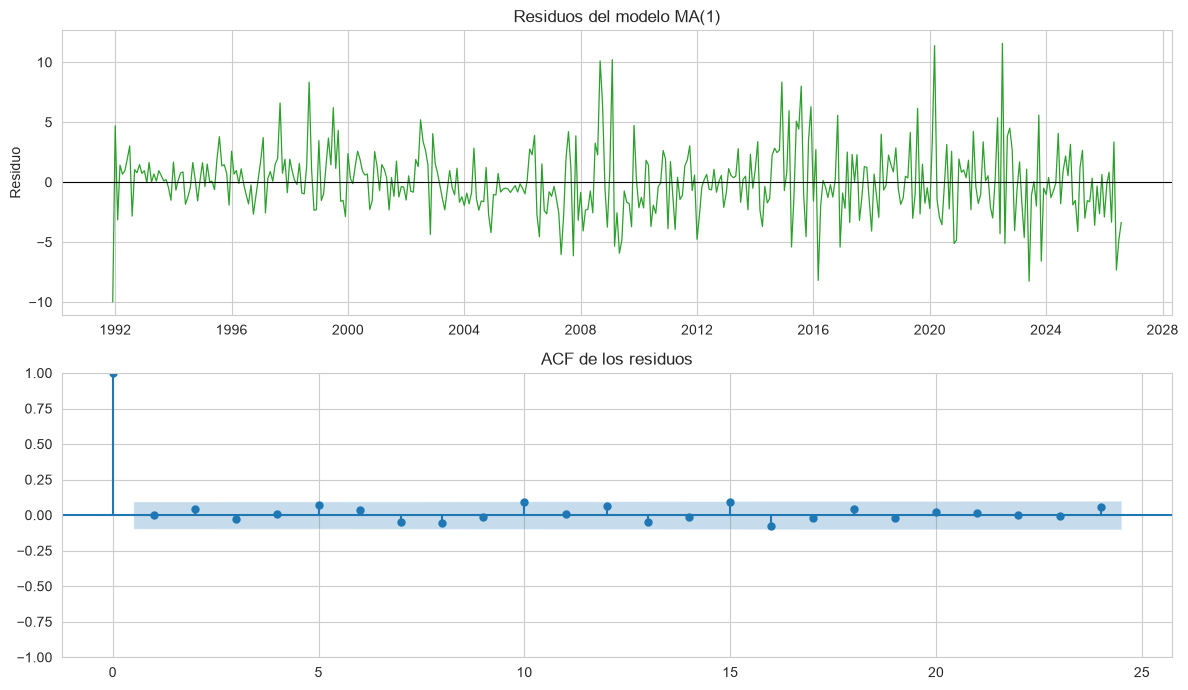

Media de los residuos: 0.005743


In [17]:
residuos = modelo_ma1.resid

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(residuos.index, residuos.values, color="#2ca02c", linewidth=0.9)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Residuos del modelo MA(1)")
axes[0].set_ylabel("Residuo")

plot_acf(residuos, lags=24, ax=axes[1])
axes[1].set_title("ACF de los residuos")

plt.tight_layout()
plt.savefig("../reports/figures/12_residuos_ma1_mensual.png", dpi=150)
plt.show()

print(f"Media de los residuos: {residuos.mean():.6f}")

In [18]:
a_res = acf(residuos, nlags=24)
banda_res = 1.96 / np.sqrt(len(residuos))

signif = [(k, round(a_res[k], 4)) for k in range(1, 25)
          if abs(a_res[k])>banda_res]

print(f"Umbral de significancia: ±{banda_res:.4f}")
print(f"Rezagos con autocorrelación significativa: {len(signif)} de 24")
print(f"Autocorrelación residual máxima en valor absoluto: "
      f"{max(abs(a_res[1:25])):.4f}")
print(f"Rezagos significativos: {signif if signif else 'ninguno'}")

Umbral de significancia: ±0.0960
Rezagos con autocorrelación significativa: 0 de 24
Autocorrelación residual máxima en valor absoluto: 0.0897
Rezagos significativos: ninguno


**Interpretación:** En la gráfica podemos observar en el panel superior como los residuos oscilan en torno a cero sin desplazamiento sistemático de su media, la cual es de 0.0057. Por otro lado, en el panel inferior la ACF de los residuos no presenta ninguna barra que sobresalga del umbral, siendo este un resultado que la salida numérica confirma, ya que **ninguno de los 24 rezagos evaluados resulta significativo** y la autocorrelación residual máxima es de 0.0897, inferior al umbral de 0.0960, a partir de esto, el modelo capturó la estructura de autocorrelación identificada en la serie. A pesar de lo mencionado, en el panel superior se aprecian tramos donde la amplitud de los residuos es visiblemente mayor, siendo esto un comportamiento que corresponde al agrupamiento de volatilidad documentado como hecho estilizado de las series financieras (Cont, 2001) y que será retomado en la sección 6. 

## 4.2 Prueba de Ljung-Box
La prueba de Ljung-Box contrasta la hipótesis nula de que los residuos son independientes, evaluando de forma conjunta las autocorrelaciones hasta un rezago dado (Ljung & Box, 1978), donde si el p-valor supera 0.05, no se rechaza la independencia y el modelo supera la etapa.

In [19]:
lb = acorr_ljungbox(residuos, lags=[6, 12, 18, 24], return_df=True)
lb["decision"] = np.where(lb["lb_pvalue"]>=0.05,
                          "No rechaza H0", "Rechaza H0")
print("H0: los residuos son independientes (ruido blanco)\n")
print(lb.round(4).to_string())

H0: los residuos son independientes (ruido blanco)

    lb_stat  lb_pvalue       decision
6    3.8621     0.6953  No rechaza H0
12  11.2805     0.5050  No rechaza H0
18  19.3460     0.3708  No rechaza H0
24  21.1387     0.6305  No rechaza H0


**Interpretación:** La prueba no rechaza la hipótesis de independencia en ninguno de los cuatro rezagos evaluados, con p-valores holgadamente superiores a 0.05 en todos los casos, por lo tanto, el modelo supera la etapa de diagnóstico y podemos concluir que especificación MA(1) describe adecuadamente la estructura de dependencia del log-retorno mensual de la TRM.

## 4.3 Normalidad de los residuos 

De forma complementaria se evalúa la normalidad mediante la prueba de Jarque-Bera, que, si bien no condiciona la validez del modelo en la media, ya que la prueba de Ljung-Box es robusta frente a innovaciones no normales (Ljung & Box, 1978), sí resulta relevante para construir intervalos de pronóstico. 

In [20]:
jb_stat, jb_p, asimetria, curtosis = jarque_bera(residuos)

print(f"Jarque-Bera: estadístico = {jb_stat:.2f} | p-valor = {jb_p:.4f}")
print(f"Asimetría = {asimetria:.4f} (0 en una distribución normal)")
print(f"Curtosis = {curtosis:.4f} (3 en una distribución normal)")
print()
print("->", "residuos normales" if jb_p >= 0.05 else "residuos No normales")

Jarque-Bera: estadístico = 101.68 | p-valor = 0.0000
Asimetría = 0.4778 (0 en una distribución normal)
Curtosis = 5.2224 (3 en una distribución normal)

-> residuos No normales


**Interpretación:** A partir de los resultados podemos concluir que la prueba rechaza la normalidad, con un p-valor inferior a 0.001, ya que, por un lado, la asimetría de 0.4778 indica una leve inclinación hacia valores positivos, es decir, hacia episodios de depreciación, mientras que por otro lado la curtosis de 5.2224 supera el valor de 3 que corresponde a una distribución normal, lo que evidencia la presencia de colas más pesadas. Estos resultados son consistentes con un comportamiento leptocúrtico para los retornos financieros (Mandelbrot, 1963; Cont, 2001) y que ya fue identificado en la unidad anterior sobre la serie diaria. El rechazo de la normalidad no invalida la estimación, dado que el estimador de máxima verosimilitud conserva sus propiedades asintóticas bajo desviaciones de este supuesto (Box et al., 2015); su consecuencia recae sobre los intervalos de pronóstico, cuya cobertura se verifica a continuación.

In [21]:
# Verificación de la cobertura de intervalos bajo el supuesto de normalidad
sigma = residuos.std(ddof=0)
print(f"Desviación estándar de los residuos: {sigma:.4f}")
print(f"{'Nivel':<8}{'Esperado fuera':>16}{'Observado fuera':>18}{'n fuera':>10}")
for z, nivel in [(1.96, "95 %"), (2.576, "99 %")]:
    fuera = np.abs(residuos) > z * sigma
    esperado = 2 * (1 - stats.norm.cdf(z)) * 100
    print(f"{nivel:<8}{esperado:>15.1f}%{fuera.mean()*100:>17.1f}%{fuera.sum():>10}")

z_max = np.abs(residuos).max() / sigma
prob_max = 2 * (1 - stats.norm.cdf(z_max))
print(f"\nResiduo de mayor magnitud: {z_max:.2f} desviaciones estándar")
print(f"Probabilidad bajo normalidad: {prob_max:.2e}")
print(f"Observaciones esperadas en n={len(residuos)}: {prob_max*len(residuos):.3f}")

Desviación estándar de los residuos: 2.7974
Nivel     Esperado fuera   Observado fuera   n fuera
95 %                5.0%              5.5%        23
99 %                1.0%              2.6%        11

Residuo de mayor magnitud: 4.14 desviaciones estándar
Probabilidad bajo normalidad: 3.52e-05
Observaciones esperadas en n=417: 0.015


**Interpretación:** Al realizar el contraste entre ambos niveles de confianza observamos que al 95 % la discrepancia es mínima con un 5.5 % de residuos frente al 5.0 % esperado, mientras que al 99 % la proporción observada asciende a 2.6 % frente al 1.0 % teórico, es decir, cerca del triple. Este patrón corresponde a lo que produce la leptocurtosis, en donde el centro de la distribución se ajusta de forma adecuada y el desajuste se concentra en las colas. Además, se suma que el residuo de mayor magnitud alcanza 4.14 desviaciones estándar, siendo este un valor cuya probabilidad bajo normalidad implicaría esperar 0.015 observaciones en una muestra de 417, de tal forma que un intervalo calibrado con cuantiles normales subestima la frecuencia de movimientos extremos de la serie. Finalmente, esta evidencia constituye un indicio de la conveniencia de modelar la varianza de forma explícita en lugar de tratarla como constante (Engle, 1982), punto que será desarrollado en la sección 6.

# 5. Dificultades observadas durante el proceso

## 5.1 La frecuencia condiciona la identificación y el diagnóstico 

La dificultad principal no consistió en ajustar un modelo sino en elegir la frecuencia sobre la cual identificarlo. Para documentarla con evidencia se replica el análisis sobre el log-retorno diario de la unidad anterior y se contrastan ambos resultados. 

In [22]:
y_diario = (np.log(trm["trm"]).diff() * 100).dropna().reset_index(drop=True)

comparacion_frec = []
for nombre, serie in [("Diaria", y_diario), ("Mensual", y)]:
    n_s = len(serie)
    banda_s = 1.96 / np.sqrt(n_s)
    a_s = acf(serie, nlags=24)
    n_sig = sum(1 for k in range(1, 25) if abs(a_s[k]) > banda_s)
    max_post = max(abs(a_s[k]) for k in range(2, 25))

    mod_s = ARIMA(serie, order=(0, 0, 1)).fit()
    lb_s = acorr_ljungbox(mod_s.resid, lags=[12], return_df=True)

    comparacion_frec.append({
        "Frecuencia": nombre,
        "n": n_s,
        "Umbral": round(banda_s, 4),
        "ACF(1)": round(a_s[1], 4),
        "Signif. de 24": n_sig,
        "Mayor ACF tras rezago 1": round(max_post, 4),
        "MA(1) theta": round(mod_s.params["ma.L1"], 4),
        "LB(12) p-valor": round(lb_s["lb_pvalue"].iloc[0], 4),
    })

print(pd.DataFrame(comparacion_frec).to_string(index=False))


Frecuencia     n  Umbral  ACF(1)  Signif. de 24  Mayor ACF tras rezago 1  MA(1) theta  LB(12) p-valor
    Diaria 12693  0.0174  0.1330             10                   0.0433       0.1398          0.0077
   Mensual   417  0.0960  0.3031              1                   0.0877       0.3212          0.5050


**Interpretación:** Al realizar el contraste se logran observar tres diferencias, una de ellas se observa con los rezagos marcados como significativos, ya que en la serie diaria el umbral es de ±0.0174 frente a ±0.0960 en la mensual, y el número de rezagos que lo superan pasa de 10 a 1. Ahora bien, la mayor autocorrelación posterior al primer rezago es de apenas 0.0433 en la serie diaria, magnitud cuyo cuadrado representa menos del 0.2% de la varianza, lo que quiere decir, que esos diez rezagos son estadísticamente significativos, pero de tamaño despreciable, lo cual dificulta reconocer el patrón de corte que la tabla de firmas de la sección 2 requiere para proponer los órdenes del modelo. 

Con lo que respecta a los resultados del diagnóstico, la prueba de Ljung-Box rechaza la independencia sobre la serie diaria y no la rechaza sobre la mensual, aun tratándose del mismo tipo de modelo. Teniendo en cuenta que la prueba acumula los cuadrados de las autocorrelaciones residuales ponderados por el tamaño muestral (Ljung & Box, 1978), con 12693 observaciones , autocorrelaciones residuales inferiores a 0.04 son suficiente para producir el rechazo. 

Para finalizar, el coeficiente de media móvil aumenta de 0.1398 a 0.3212 al pasar a la frecuencia mensual y este último se aproxima más al 0.25 que predice el efecto de agregación temporal (Working, 1960). Lo anterior resulta coherente, ya que el promedio mensual constituye una agregación más prolongada que el de una jornada, de tal forma que el efecto se manifiesta con mayor nitidez. 


## 5.2 Otras dificultades
Algunas dificultades adicionales encontradas fueron que la firma gráfica no discrimina entre AR(1) y MA(1), ya que, con un único coeficiente significativo en el primer rezago, ambas especificaciones producen patrones muy similares en la ACF y la PACF, tal como se advirtió en la sección 2.2. Teniendo esto en cuenta, las reglas de identificación resultan insuficientes por sí solas y es necesario recurrir a criterios de información, a la significancia de parámetros y al argumento teórico sobre el mecanismo de construcción de la serie. 

Por otro lado, se observó que el criterio de AIC no discrimina entre especificaciones cercanas, esto debido a que el modelo de menor AIC de la grilla fue un ARMA(2,3), que supera al MA(1) en 0.62 unidades utilizando cuatro parámetros adicionales, diferencia que deja a ambos dentro del rango de apoyo sustancial (Burnham & Anderson, 2002). Debido a esto seleccionar por AIC mínimo sin considerar fla parsimonia habría conducido a un modelo innecesariamente complejo y como se observó, en el ARMA(1,1), los coeficientes dejan de ser significativos entre sí. 

Con respecto a la estructura identificada, se concluye que esta no admite una lectura económica directa, ya que el coeficiente de 0.3212 no refleja una oportunidad de predicción del mercado cambiario, sino el efecto de agregación temporal derivado de que la TRM se construye como un promedio (Working, 1960), esta distinción es relevante, puesto que un modelo estadísticamente válido no implica por sí mismo capacidad de pronóstico aprovechable. 

Finalmente, el modelo no logra capturar la dinámica de la varianza, esto debido a que en el diagnóstico se evidenció la presencia de residuos no correlacionados, pero no normales, además, su gráfico exhibe tramos de amplitud variable, y teniendo en cuenta que los modelos de la familia ARMA construyen la varianza como una constante, el comportamiento de la misma queda por fuera de su alcance. 


---
# 6. Síntesis y trabajo futuro
|Etapa | Resultado |
|---|---|
|Identificación | Un único coeficiente significativo en el primer rezago de ACF y PACF, compatible con la hipótesis de agregación temporal. Modelos tentativos: AR(1), MA(1) y ARMA(1,1) |
|**Estimación** | MA(1) seleccionado por criterios de información y parsimonia. $y_t = 0.3498 + \varepsilon_t + 0.3212\, \varepsilon_{t-1}$ |
|**Diagnóstico** | Ljung-Box no rechaza en ningún rezago y ningún coeficiente residual resulta significativo. El modelo supera la etapa. 

El modelo describe adecuadamente la estructura de dependencia de la media del log-retorno mensual de la TRM, ya que su media móvil de primer orden y la magnitud de su coeficiente concuerdan con la predicción planteada en la sección 2.1 a partir del efecto de agregación temporal (Working, 1960), de modo que la estructura identificada se explica por el método de cálculo del indicador y no por el comportamiento del mercado cambiario. 

**Trabajo futuro:** El diagnostico deja abierto un elemento que este modelo no logra abordar, ya que los residuos resultaron no correlacionados y a su vez con una curtosis de 5.2224, además de un gráfico que exhibe tramos de amplitud variable, estos rasgos apuntan a una varianza condicional, que cambia en el tiempo. Los modelos de heterocedasticidad condicional autorregresiva fueron formulados precisamente para capturar este comportamiento (Engle, 1982) y posteriormente generalizados por Bollerslev (1986). Debido a esto, para la etapa final del proyecto resulta apropiado explorar esa familia sobre la serie diaria, cuya mayor frecuencia proporciona el número de observaciones que tal especificación requiere y en la cual el agrupamiento de volatilidad se manifiesta con mayor claridad (Cont, 2001).


---
# Referencias

Akaike, H. (1974). A new look at the statistical model identification. *IEEE
Transactions on Automatic Control, 19*(6), 716-723.

Banco de la República. (2018). *Circular Reglamentaria Externa DODM-146.
Asunto 8: Metodología de cálculo de la tasa de cambio representativa del
mercado*.

Banco de la República. (2026). *Tasa Representativa del Mercado (TRM). Serie
diaria 1991-2026* [Conjunto de datos]. Portal de Estadísticas Económicas.

Bollerslev, T. (1986). Generalized autoregressive conditional
heteroskedasticity. *Journal of Econometrics, 31*(3), 307-327.

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time
Series Analysis: Forecasting and Control* (5.ª ed.). Wiley.

Burnham, K. P., & Anderson, D. R. (2002). *Model Selection and Multimodel
Inference: A Practical Information-Theoretic Approach* (2.ª ed.). Springer.

Cont, R. (2001). Empirical properties of asset returns: Stylized facts and
statistical issues. *Quantitative Finance, 1*(2), 223-236.

Dickey, D. A., & Fuller, W. A. (1979). Distribution of the estimators for
autoregressive time series with a unit root. *Journal of the American
Statistical Association, 74*(366), 427-431.

Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with
estimates of the variance of United Kingdom inflation. *Econometrica, 50*(4),
987-1007.

Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical
work. *The Journal of Finance, 25*(2), 383-417.

Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., & Shin, Y. (1992). Testing
the null hypothesis of stationarity against the alternative of a unit root.
*Journal of Econometrics, 54*(1-3), 159-178.

Ljung, G. M., & Box, G. E. P. (1978). On a measure of lack of fit in time
series models. *Biometrika, 65*(2), 297-303.

Mandelbrot, B. (1963). The variation of certain speculative prices. *The
Journal of Business, 36*(4), 394-419.

Schwarz, G. (1978). Estimating the dimension of a model. *The Annals of
Statistics, 6*(2), 461-464.

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical
modeling with Python. *Proceedings of the 9th Python in Science Conference*,
92-96.

Working, H. (1960). Note on the correlation of first differences of averages in
a random chain. *Econometrica, 28*(4), 916-918.